# Primera evidencia

**Pregunta:** ¿Como varia la proporcion de CVE presentes en CISA KEV segun su vector de ataque?

El resultado es descriptivo. No demuestra causalidad y `in_kev = 0` no significa ausencia de explotacion.

In [1]:
from pathlib import Path
import os
import pandas as pd

root = Path.cwd()
if not (root / "README.md").exists():
    root = root.parent
(root / ".matplotlib").mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(root / ".matplotlib"))
import matplotlib.pyplot as plt
processed = root / "data" / "processed" / "vulnerabilities_2025_q1.csv"
sample = root / "data" / "sample" / "analytical_sample_2025_q1.csv"
data_path = processed if processed.exists() else sample
df = pd.read_csv(data_path)
for column in ["published", "last_modified", "date_added", "due_date"]:
    df[column] = pd.to_datetime(df[column], errors="coerce", utc=True)
print(f"Dataset: {data_path.relative_to(root)}")
print("Los resultados corresponden al archivo indicado arriba.")

Dataset: data\processed\vulnerabilities_2025_q1.csv
Los resultados corresponden al archivo indicado arriba.


## Tabla por vector de ataque

In [2]:
analysis = df.assign(attack_vector=df["attack_vector"].fillna("MISSING"))
table = (analysis.groupby("attack_vector", dropna=False)
         .agg(total_cves=("cve_id", "size"), cves_in_kev=("in_kev", "sum"))
         .reset_index())
table["percent_in_kev"] = (table["cves_in_kev"] / table["total_cves"] * 100).round(4)
table = table.sort_values(["percent_in_kev", "total_cves"], ascending=[False, False])
print(f"Total de CVE: {len(df):,}")
print(f"CVE presentes en KEV: {int(df['in_kev'].sum()):,}")
display(table)

Total de CVE: 12,412
CVE presentes en KEV: 58


,attack_vector,total_cves,cves_in_kev,percent_in_kev
5,PHYSICAL,134,2,1.4925
2,LOCAL,2774,15,0.5407
4,NETWORK,8745,41,0.4688
3,MISSING,466,0,0.0000
1,ADJACENT_NETWORK,196,0,0.0000
0,ADJACENT,97,0,0.0000


## Grafica

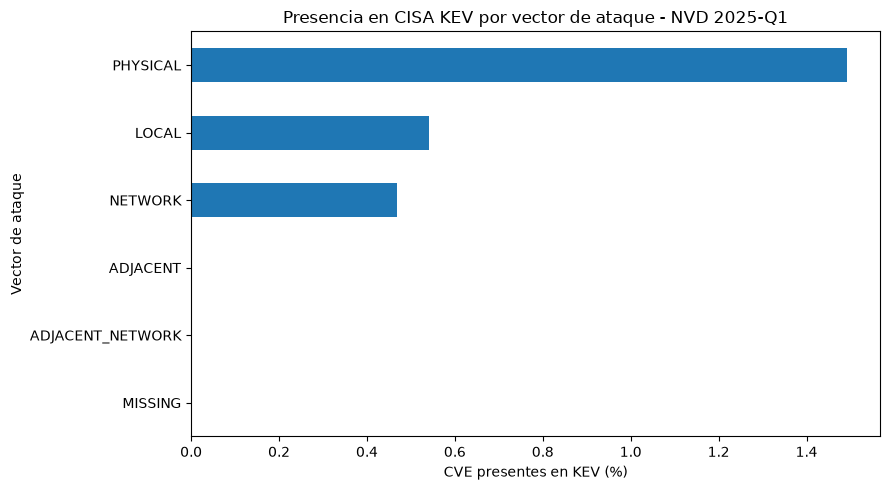

In [3]:
figures = root / "reports" / "figures"
tables = root / "reports" / "tables"
figures.mkdir(parents=True, exist_ok=True)
tables.mkdir(parents=True, exist_ok=True)
table.to_csv(tables / "kev_by_attack_vector_2025_q1.csv", index=False)
plot_table = table.sort_values("percent_in_kev")
ax = plot_table.plot.barh(x="attack_vector", y="percent_in_kev", legend=False, figsize=(9, 5), color="#1f77b4")
ax.set_xlabel("CVE presentes en KEV (%)")
ax.set_ylabel("Vector de ataque")
ax.set_title("Presencia en CISA KEV por vector de ataque - NVD 2025-Q1")
plt.tight_layout()
plt.savefig(figures / "kev_by_attack_vector_2025_q1.png", dpi=180, bbox_inches="tight")
plt.show()

## Interpretacion

In [4]:
ranked = table[table["total_cves"] > 0]
highest = ranked.iloc[0]
print(
    f"En este corte, {highest['attack_vector']} muestra la mayor proporcion observada: "
    f"{highest['percent_in_kev']:.4f}% ({int(highest['cves_in_kev'])} de {int(highest['total_cves'])})."
)
print("Las diferencias son asociaciones descriptivas; no prueban causalidad.")

En este corte, PHYSICAL muestra la mayor proporcion observada: 1.4925% (2 de 134).
Las diferencias son asociaciones descriptivas; no prueban causalidad.
